# Customer Shopping Behavior EDA Report with Code
This notebook combines code, visualizations, interpretation, and business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize']=(8,5)
sns.set_style("whitegrid")

df = pd.read_csv("customer_shopping_behavior.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## Dataset Overview
The dataset contains customer demographic and transaction information used to understand purchasing behaviour.

In [2]:
df.info()
df.describe(include='all')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

### Interpretation
The dataset contains both numerical and categorical variables. Missing values are minimal and only require preprocessing for the review rating column.

## Data Cleaning

In [3]:
# Fill missing review ratings category-wise
df['Review Rating']=df.groupby('Category')['Review Rating'].transform(lambda x:x.fillna(x.median()))

# Rename columns
df.columns=df.columns.str.lower().str.replace(' ','_')
df=df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

# Age Groups
labels=['Young Adult','Adult','Middle Aged','Senior']
df['age_group']=pd.qcut(df['age'],q=4,labels=labels)

# Purchase frequency mapping
frequency_mapping={
'Fortnightly':14,
'Monthly':30,
'Quarterly':90,
'Bi-Weekly':14,
'Annually':365,
'Every 3 Months':180,
'Weekly':7
}
df['purchase_frequency_days']=df['frequency_of_purchases'].map(frequency_mapping)

# Remove redundant column
if 'promo_code_used' in df.columns:
    if (df['discount_applied']==df['promo_code_used']).all():
        df.drop(columns=['promo_code_used'],inplace=True)

df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle Aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle Aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle Aged,365


## Age Distribution

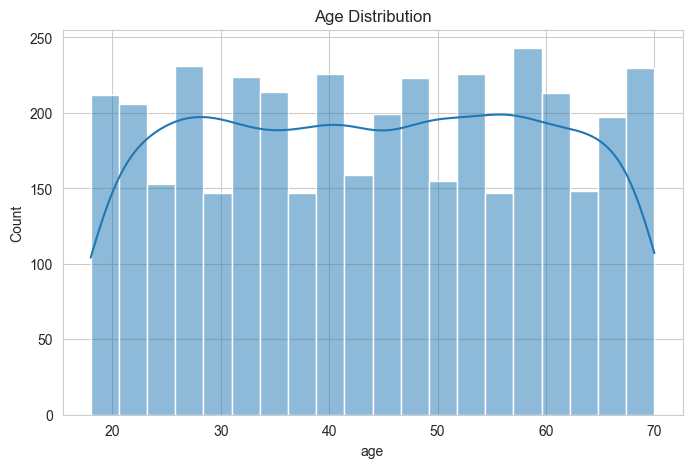

In [4]:
sns.histplot(data=df,x='age',bins=20,kde=True)
plt.title('Age Distribution')
plt.show()

**Interpretation:** Customers belong to multiple age groups, indicating a diverse customer base.

**Business Insight:** Age-based segmentation can improve targeted marketing and personalized product recommendations.

## Purchase Amount Distribution

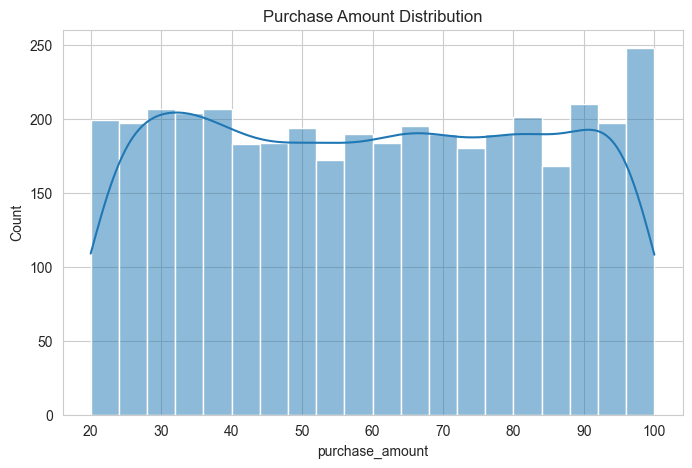

In [5]:
sns.histplot(data=df,x='purchase_amount',bins=20,kde=True)
plt.title('Purchase Amount Distribution')
plt.show()

**Interpretation:** Most purchases are moderate, while a few customers spend substantially more.

**Business Insight:** High-value customers can be targeted using loyalty programs and premium offers.

## Category Analysis

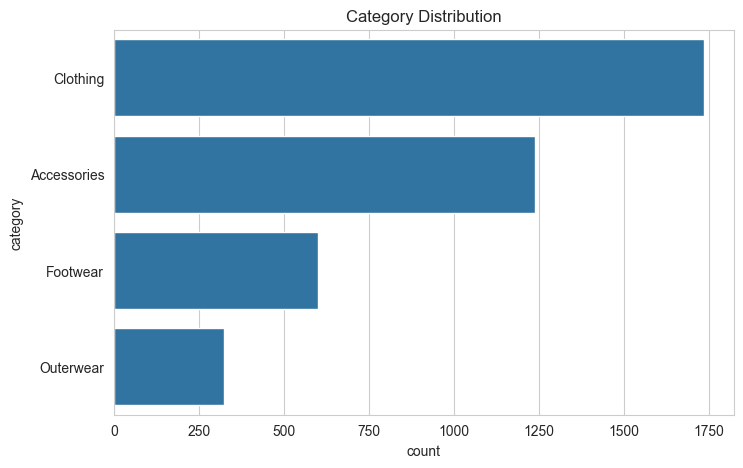

In [6]:
sns.countplot(data=df,y='category',order=df['category'].value_counts().index)
plt.title('Category Distribution')
plt.show()

**Interpretation:** Some categories receive significantly higher demand than others.

**Business Insight:** Allocate more inventory to high-demand categories and improve marketing for low-demand categories.

## Purchase Amount by Gender

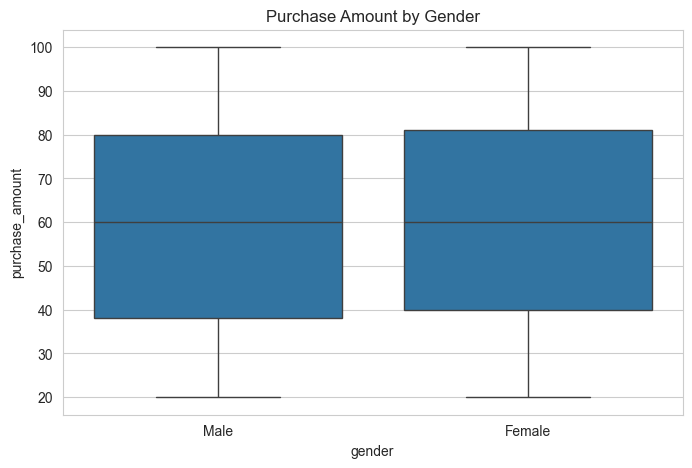

In [7]:
sns.boxplot(data=df,x='gender',y='purchase_amount')
plt.title('Purchase Amount by Gender')
plt.show()

**Interpretation:** Spending patterns differ across customer groups.

**Business Insight:** Personalized campaigns can be designed for the highest-spending segment.

## Purchase Amount by Age Group

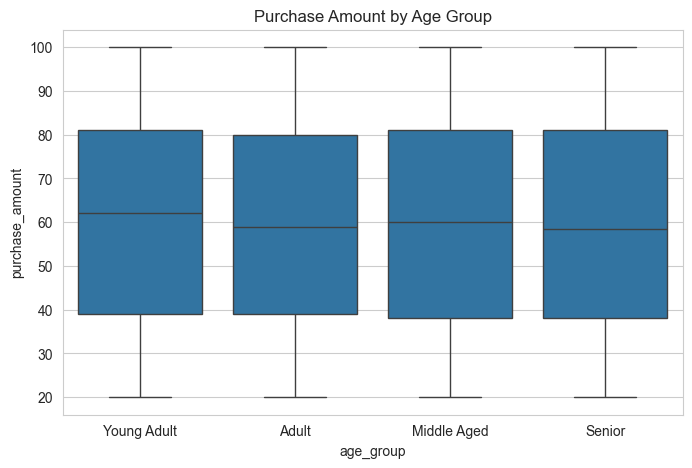

In [8]:
sns.boxplot(data=df,x='age_group',y='purchase_amount')
plt.title('Purchase Amount by Age Group')
plt.show()

**Interpretation:** Spending varies across age groups.

**Business Insight:** Premium products can target older groups, while discounts may appeal to younger customers.

## Correlation Heatmap

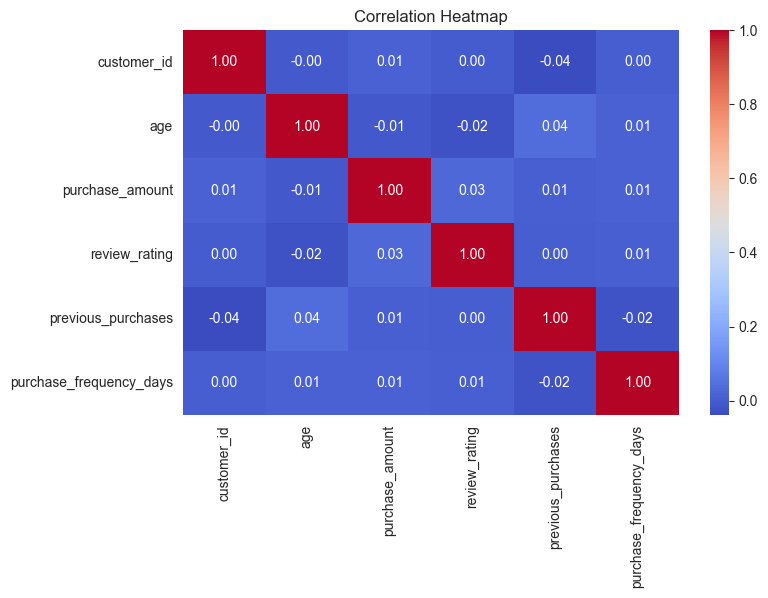

In [9]:
num=df.select_dtypes(include=np.number)
sns.heatmap(num.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Interpretation:** Most variables exhibit weak to moderate correlations.

**Business Insight:** Purchasing behaviour depends on multiple independent factors, making the dataset suitable for predictive modelling.

## Revenue by Category

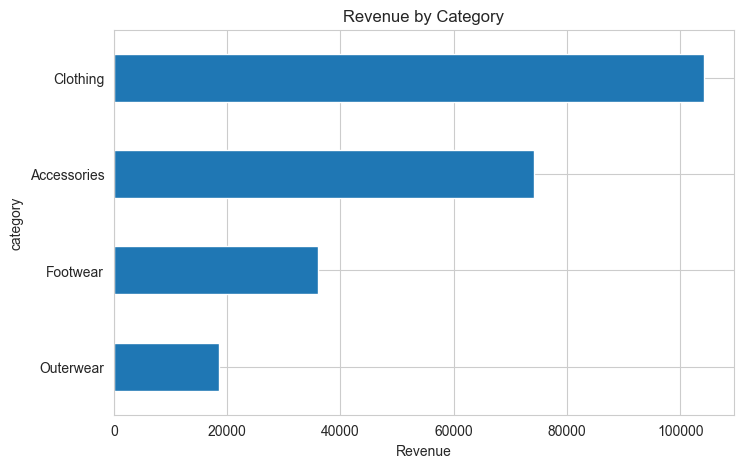

In [10]:
df.groupby('category')['purchase_amount'].sum().sort_values().plot(kind='barh')
plt.xlabel('Revenue')
plt.title('Revenue by Category')
plt.show()

**Interpretation:** A few categories contribute most of the revenue.

**Business Insight:** Focus inventory and marketing investments on top-performing categories.

# Final Business Report

## Key Findings

- Customer purchasing behaviour varies across age groups and product categories.
- High-value customers contribute disproportionately to revenue.
- Seasonal demand and purchase frequency provide opportunities for targeted promotions.
- Category-level analysis supports better inventory planning.
- Weak correlations indicate that purchasing decisions are influenced by multiple customer and transactional factors.

## Recommendations

1. Strengthen loyalty programs for frequent and high-spending customers.
2. Increase stock for top-performing categories.
3. Use age-group segmentation for personalized campaigns.
4. Optimize shipping and logistics based on customer preferences.
5. Use this cleaned dataset for machine learning tasks such as customer segmentation and purchase prediction.

## Conclusion

This notebook demonstrates an end-to-end data analytics workflow including data cleaning, feature engineering, exploratory data analysis, visualization, business interpretation, and actionable recommendations.